# 🍅 Tomato Leaf Disease Classification — EfficientNetB0 (Colab Edition)

This notebook has been adapted to run end-to-end on **Google Colab**. Before running:

1. `Runtime → Change runtime type → T4 GPU` (or better) for reasonable training speed.
2. Have the `PlantVillage.zip` dataset ready — either already in your Google Drive, or on your local machine to upload when prompted.
3. Run the cells top-to-bottom.


In [1]:
# ── Colab environment setup ────────────────────────────────────────────────
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"Running in Colab: {IN_COLAB}")

# Set to True to persist data/models in Google Drive across sessions.
# Set to False to keep everything in the (ephemeral) Colab VM disk.
MOUNT_DRIVE = False

if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/PlantVillage_Project')
else:
    BASE_DIR = Path('/content/PlantVillage_Project')

# ── Central project paths (used throughout the notebook instead of "../data") ─
DATA_DIR      = BASE_DIR / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR    = BASE_DIR / "models"

for d in [RAW_DIR, PROCESSED_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Base directory : {BASE_DIR}")
print(f"Raw data       : {RAW_DIR}")
print(f"Processed data : {PROCESSED_DIR}")
print(f"Models         : {MODELS_DIR}")

# ── Data Download (PlantVillage.zip) ─────────────────────────────────────────
RAW_ZIP = RAW_DIR / "PlantVillage.zip"
GDOWN_FILE_ID = "11_hdxZUiFGW7NQ3voRJ-lFB9fBcHIwA8" # Extracted from the URL

if IN_COLAB and not RAW_ZIP.exists():
    print(f"\nDownloading {RAW_ZIP.name} from Google Drive...")
    try:
        # Install gdown if not already available
        try:
            import gdown
        except ImportError:
            %pip install gdown -qq
            import gdown

        gdown.download(id=GDOWN_FILE_ID, output=str(RAW_ZIP), quiet=False)
        print(f"Downloaded {RAW_ZIP.name} to {RAW_ZIP}")
    except Exception as e:
        print(f"Error downloading {RAW_ZIP.name}: {e}")
elif not IN_COLAB and not RAW_ZIP.exists():
    print(f"\nSkipping automatic download outside Colab. Please place {RAW_ZIP.name} at {RAW_ZIP} manually.")
else:
    print(f"\n{RAW_ZIP.name} already exists at {RAW_ZIP}. Skipping download.")

Running in Colab: True
Base directory : /content/PlantVillage_Project
Raw data       : /content/PlantVillage_Project/data/raw
Processed data : /content/PlantVillage_Project/data/processed
Models         : /content/PlantVillage_Project/models



Downloading...
From (original): https://drive.google.com/uc?id=11_hdxZUiFGW7NQ3voRJ-lFB9fBcHIwA8
From (redirected): https://drive.google.com/uc?id=11_hdxZUiFGW7NQ3voRJ-lFB9fBcHIwA8&confirm=t&uuid=f937af45-053c-4a87-9e75-ad7b0d6806a8
To: /content/PlantVillage_Project/data/raw/PlantVillage.zip
100%|██████████| 148M/148M [00:04<00:00, 34.4MB/s]

Downloaded PlantVillage.zip to /content/PlantVillage_Project/data/raw/PlantVillage.zip


In [2]:
# ── Confirm GPU is available ────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → select a GPU, "
          "then re-run this cell. Training EfficientNetB0 on CPU will be very slow.")


GPU detected: ['/physical_device:GPU:0']


In [3]:
# ── Get PlantVillage.zip onto the Colab filesystem ─────────────────────────
RAW_ZIP = RAW_DIR / "PlantVillage.zip"

if RAW_ZIP.exists():
    print(f"Found existing dataset zip at {RAW_ZIP}")
else:
    if IN_COLAB:
        # Option A: the zip already lives somewhere in your Drive — point to it here
        # and it will be copied in automatically. Leave as None to skip this option.
        DRIVE_ZIP_PATH = None  # e.g. "/content/drive/MyDrive/datasets/PlantVillage.zip"

        if DRIVE_ZIP_PATH and Path(DRIVE_ZIP_PATH).expanduser().exists():
            shutil.copy(Path(DRIVE_ZIP_PATH).expanduser(), RAW_ZIP)
            print(f"Copied dataset from Drive to {RAW_ZIP}")
        else:
            # Option B: upload it directly from your computer
            print("PlantVillage.zip not found. Please choose the file to upload...")
            from google.colab import files
            uploaded = files.upload()
            uploaded_name = next(iter(uploaded.keys()))
            shutil.move(uploaded_name, RAW_ZIP)
            print(f"Uploaded and saved dataset to {RAW_ZIP}")
    else:
        raise FileNotFoundError(
            f"Please place PlantVillage.zip at {RAW_ZIP} before continuing."
        )


Found existing dataset zip at /content/PlantVillage_Project/data/raw/PlantVillage.zip


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
import zipfile

# ── Paths (now defined once in the setup cell above) ───────────────────────
TEMP_DIR  = RAW_DIR / "PlantVillage_temp"   # temporary extraction – NOT processed/
PROCESSED = PROCESSED_DIR

# ── Extract to temp only if not already done ──────────────────────────────────
if TEMP_DIR.exists() and any(TEMP_DIR.iterdir()):
    print(f"Already extracted to temp dir: {TEMP_DIR}")
else:
    TEMP_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {RAW_ZIP.name} -> {TEMP_DIR} ...")
    with zipfile.ZipFile(RAW_ZIP, "r") as zf:
        zf.extractall(TEMP_DIR)
    print("Extraction complete!")

# ── Ensure processed/ exists ──────────────────────────────────────────────────
PROCESSED.mkdir(parents=True, exist_ok=True)
print(f"\nTemp dir  : {TEMP_DIR}")
print(f"Processed : {PROCESSED}  <- only train/ val/ test/ will live here")


Extracting PlantVillage.zip -> /content/PlantVillage_Project/data/raw/PlantVillage_temp ...
Extraction complete!

Temp dir  : /content/PlantVillage_Project/data/raw/PlantVillage_temp
Processed : /content/PlantVillage_Project/data/processed  <- only train/ val/ test/ will live here


In [6]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                       = RAW_DIR / "PlantVillage_temp"
target_train_dir               = PROCESSED_DIR / "train"
num_images_per_class_for_train = 600

# ── Find class folders inside temp extraction ─────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

if source_data_root is None:
    print(f"Error: Could not find class folders under {TEMP_DIR}.")
    print("Check the zip structure — expected PlantVillage_Dataset/color/CLASS_NAME.")
else:
    print(f"Found source data root: {source_data_root}")

    # ── Create/clean train dir ────────────────────────────────────────────────
    if target_train_dir.exists():
        print(f"Removing existing train dir: {target_train_dir}")
        shutil.rmtree(target_train_dir)
    target_train_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created: {target_train_dir}")

    # ── Copy selected images per class ────────────────────────────────────────
    all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])
    print(f"Detected classes ({len(all_classes)}): {all_classes}")

    for class_name in all_classes:
        source_class_dir = source_data_root / class_name
        dest_class_dir   = target_train_dir / class_name
        dest_class_dir.mkdir(parents=True, exist_ok=True)

        images = []
        for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
            images.extend(list(source_class_dir.glob(ext)))

        if not images:
            print(f"  Warning: no images in {source_class_dir}. Skipping.")
            continue

        random.seed(42)
        random.shuffle(images)
        selected = images[:num_images_per_class_for_train]

        for img in selected:
            shutil.copy(img, dest_class_dir / img.name)
        print(f"  {class_name}: {len(selected)} images copied")

    print("\nTraining dataset ready at:", target_train_dir)


Found source data root: /content/PlantVillage_Project/data/raw/PlantVillage_temp/PlantVillage
Created: /content/PlantVillage_Project/data/processed/train
Detected classes (6): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_healthy']
  Tomato_Bacterial_spot: 600 images copied
  Tomato_Early_blight: 600 images copied
  Tomato_Late_blight: 600 images copied
  Tomato_Leaf_Mold: 600 images copied
  Tomato__Target_Spot: 600 images copied
  Tomato_healthy: 600 images copied

Training dataset ready at: /content/PlantVillage_Project/data/processed/train


In [7]:
IMAGE_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
SEED = 42

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="reflect"
)

train_generator = train_gen.flow_from_directory(
    str(target_train_dir),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True,
    seed=SEED
)

Found 3600 images belonging to 6 classes.


In [8]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                     = RAW_DIR / "PlantVillage_temp"
target_val_dir               = PROCESSED_DIR / "val"
train_root_dir               = PROCESSED_DIR / "train"
num_images_per_class_for_val = 150

print("Starting validation dataset preparation...")

# ── Find class folders ────────────────────────────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])

# ── Create/clean val dir ──────────────────────────────────────────────────────
if target_val_dir.exists():
    print(f"Removing existing val dir: {target_val_dir}")
    shutil.rmtree(target_val_dir)
target_val_dir.mkdir(parents=True, exist_ok=True)
print(f"Created: {target_val_dir}")

# ── Collect already-used training images ──────────────────────────────────────
images_in_train = set()
for class_name in all_classes:
    class_train_path = train_root_dir / class_name
    if class_train_path.is_dir():
        for img_path in class_train_path.iterdir():
            images_in_train.add(img_path.resolve())
print(f"Training images to exclude: {len(images_in_train)}")

# ── Populate val dir ──────────────────────────────────────────────────────────
random.seed(SEED)
for class_name in all_classes:
    source_class_dir = source_data_root / class_name
    dest_class_dir   = target_val_dir / class_name
    dest_class_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = []
    for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
        all_imgs.extend(list(source_class_dir.glob(ext)))

    available = [p for p in all_imgs if p.resolve() not in images_in_train]
    random.shuffle(available)
    selected = available[:num_images_per_class_for_val]

    if not selected:
        print(f"  Warning: no unique images for val in '{class_name}'. Skipping.")
        continue

    for img in selected:
        shutil.copy(img, dest_class_dir / img.name)
    print(f"  {class_name}: {len(selected)} images copied")

print("\nValidation dataset ready at:", target_val_dir)

# ── ImageDataGenerator for validation ─────────────────────────────────────────
valid_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_generator = valid_gen.flow_from_directory(
    str(target_val_dir),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Starting validation dataset preparation...
Created: /content/PlantVillage_Project/data/processed/val
Training images to exclude: 3600
  Tomato_Bacterial_spot: 150 images copied
  Tomato_Early_blight: 150 images copied
  Tomato_Late_blight: 150 images copied
  Tomato_Leaf_Mold: 150 images copied
  Tomato__Target_Spot: 150 images copied
  Tomato_healthy: 150 images copied

Validation dataset ready at: /content/PlantVillage_Project/data/processed/val
Found 900 images belonging to 6 classes.


In [9]:
import os
import shutil
import random
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
TEMP_DIR                      = RAW_DIR / "PlantVillage_temp"
target_test_dir               = PROCESSED_DIR / "test"
train_root_dir                = PROCESSED_DIR / "train"
val_root_dir                  = PROCESSED_DIR / "val"
num_images_per_class_for_test = 150

print("Starting test dataset preparation...")

# ── Find class folders ────────────────────────────────────────────────────────
source_data_root = None
for root, dirs, files in os.walk(TEMP_DIR):
    if any("Tomato" in d for d in dirs) and len(dirs) > 1:
        source_data_root = Path(root)
        break

all_classes = sorted([d.name for d in source_data_root.iterdir() if d.is_dir()])

# ── Create/clean test dir ─────────────────────────────────────────────────────
if target_test_dir.exists():
    print(f"Removing existing test dir: {target_test_dir}")
    shutil.rmtree(target_test_dir)
target_test_dir.mkdir(parents=True, exist_ok=True)
print(f"Created: {target_test_dir}")

# ── Collect already-used train + val images ───────────────────────────────────
used_images = set()
for class_name in all_classes:
    for split_dir in [train_root_dir, val_root_dir]:
        class_path = split_dir / class_name
        if class_path.is_dir():
            for img_path in class_path.iterdir():
                used_images.add(img_path.resolve())
print(f"Train + val images to exclude: {len(used_images)}")

# ── Populate test dir ─────────────────────────────────────────────────────────
random.seed(SEED)
for class_name in all_classes:
    source_class_dir = source_data_root / class_name
    dest_class_dir   = target_test_dir / class_name
    dest_class_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = []
    for ext in ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]:
        all_imgs.extend(list(source_class_dir.glob(ext)))

    available = [p for p in all_imgs if p.resolve() not in used_images]
    random.shuffle(available)
    selected = available[:num_images_per_class_for_test]

    if not selected:
        print(f"  Warning: no unique images for test in '{class_name}'. Skipping.")
        continue

    for img in selected:
        shutil.copy(img, dest_class_dir / img.name)
    print(f"  {class_name}: {len(selected)} images copied")

print("\nTest dataset ready at:", target_test_dir)

# ── Clean up temp extraction (no longer needed) ───────────────────────────────
print(f"\nCleaning up temp extraction: {TEMP_DIR} ...")
shutil.rmtree(TEMP_DIR)
print("Temp folder removed. processed/ now contains ONLY: train/ val/ test/")

# ── ImageDataGenerator for test ───────────────────────────────────────────────
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_gen.flow_from_directory(
    str(target_test_dir),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Starting test dataset preparation...
Created: /content/PlantVillage_Project/data/processed/test
Train + val images to exclude: 4500
  Tomato_Bacterial_spot: 150 images copied
  Tomato_Early_blight: 150 images copied
  Tomato_Late_blight: 150 images copied
  Tomato_Leaf_Mold: 150 images copied
  Tomato__Target_Spot: 150 images copied
  Tomato_healthy: 150 images copied

Test dataset ready at: /content/PlantVillage_Project/data/processed/test

Cleaning up temp extraction: /content/PlantVillage_Project/data/raw/PlantVillage_temp ...
Temp folder removed. processed/ now contains ONLY: train/ val/ test/
Found 900 images belonging to 6 classes.


In [10]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 6

base_model = EfficientNetB0(
    include_top=False,
    input_shape=input_shape,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False  # freeze backbone for a stable warmup

model = models.Sequential([
    layers.Input(shape=input_shape),
    base_model,
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [13]:
train_steps = len(train_generator)
valid_steps = len(valid_generator)
train_steps, valid_steps

(113, 29)

In [14]:
import numpy as np

# ── Fix: normalize EagerTensor log values to plain Python floats ──────────────
# Keras callbacks (ModelCheckpoint, ReduceLROnPlateau) call json.dumps on epoch
# logs. In some TF versions metric values are EagerTensors which aren't JSON-
# serializable. This callback runs first and converts them.
class NormalizeLogsCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs:
            for k in list(logs.keys()):
                v = logs[k]
                if hasattr(v, 'numpy'):
                    arr = v.numpy()
                    logs[k] = float(arr) if arr.ndim == 0 else arr.tolist()
                elif isinstance(v, np.ndarray):
                    logs[k] = v.tolist() if v.ndim > 0 else float(v)
                elif isinstance(v, np.floating):
                    logs[k] = float(v)

normalize_logs = NormalizeLogsCallback()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    str(MODELS_DIR / "best_effnetb0.keras"),
    monitor="val_loss",
    save_best_only=True
)


In [15]:
import os
from pathlib import Path

def count_images_in_dataset(base_dir_name=None):
    base_dir = Path(base_dir_name) if base_dir_name is not None else PROCESSED_DIR
    if not base_dir.exists():
        print(f"Error: Base directory '{base_dir}' not found.")
        return

    print(f"\n--- Image counts in '{base_dir}' subdirectories ---")

    sub_dirs = ["train", "val", "test"]
    image_extensions = ["*.JPG", "*.jpg", "*.png", "*.jpeg", "*.webp"]

    total_dataset_images = 0

    for sub_dir_name in sub_dirs:
        current_dir = base_dir / sub_dir_name
        if not current_dir.is_dir():
            print(f"Directory '{current_dir}' not found. Skipping.")
            continue

        print(f"\n-- {sub_dir_name.capitalize()} Set --")
        total_sub_dir_images = 0

        class_dirs = sorted([d for d in current_dir.iterdir() if d.is_dir()])

        if not class_dirs:
            print(f"No class directories found in '{current_dir}'.")
            continue

        for class_dir in class_dirs:
            class_name = class_dir.name
            image_count = 0
            for ext in image_extensions:
                image_count += len(list(class_dir.glob(ext)))
            print(f"  Class '{class_name}': {image_count} images")
            total_sub_dir_images += image_count
        print(f"Total images in {sub_dir_name.capitalize()} Set: {total_sub_dir_images}")
        total_dataset_images += total_sub_dir_images

    print(f"\nTotal images across all sets in '{base_dir}': {total_dataset_images}")

# Call the function to count images
count_images_in_dataset()



--- Image counts in '/content/PlantVillage_Project/data/processed' subdirectories ---

-- Train Set --
  Class 'Tomato_Bacterial_spot': 600 images
  Class 'Tomato_Early_blight': 600 images
  Class 'Tomato_Late_blight': 600 images
  Class 'Tomato_Leaf_Mold': 600 images
  Class 'Tomato__Target_Spot': 600 images
  Class 'Tomato_healthy': 600 images
Total images in Train Set: 3600

-- Val Set --
  Class 'Tomato_Bacterial_spot': 150 images
  Class 'Tomato_Early_blight': 150 images
  Class 'Tomato_Late_blight': 150 images
  Class 'Tomato_Leaf_Mold': 150 images
  Class 'Tomato__Target_Spot': 150 images
  Class 'Tomato_healthy': 150 images
Total images in Val Set: 900

-- Test Set --
  Class 'Tomato_Bacterial_spot': 150 images
  Class 'Tomato_Early_blight': 150 images
  Class 'Tomato_Late_blight': 150 images
  Class 'Tomato_Leaf_Mold': 150 images
  Class 'Tomato__Target_Spot': 150 images
  Class 'Tomato_healthy': 150 images
Total images in Test Set: 900

Total images across all sets in '/cont

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=30,
    callbacks=[normalize_logs, early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 124s 831ms/step - accuracy: 0.4211 - loss: 1.4771 - val_accuracy: 0.7478 - val_loss: 0.9777 - learning_rate: 1.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 57s 503ms/step - accuracy: 0.6772 - loss: 0.9719 - val_accuracy: 0.7956 - val_loss: 0.6760 - learning_rate: 1.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 55s 487ms/step - accuracy: 0.7494 - loss: 0.7453 - val_accuracy: 0.8611 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 54s 483ms/step - accuracy: 0.7925 - loss: 0.6268 - val_accuracy: 0.8589 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 54s 474ms/step - accuracy: 0.8172 - loss: 0.5632 - val_accuracy: 0.8856 - val_loss: 0.3861 - learning_rate: 1.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 54s 475ms/step - accuracy: 0.8239 - loss: 0.5182 - val_accuracy: 0.8911 - val_loss: 0.3633 - learning_rate: 1.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 55s 4

In [17]:
# Fine-tune upper layers once warmup converges
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

fine_tune_epochs = 10
history_ft = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=fine_tune_epochs,
    callbacks=[normalize_logs, early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 118s 743ms/step - accuracy: 0.8264 - loss: 0.5637 - val_accuracy: 0.9244 - val_loss: 0.2232 - learning_rate: 3.0000e-05
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 96s 498ms/step - accuracy: 0.8772 - loss: 0.3782 - val_accuracy: 0.9367 - val_loss: 0.1937 - learning_rate: 3.0000e-05
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 57s 501ms/step - accuracy: 0.9047 - loss: 0.3016 - val_accuracy: 0.9389 - val_loss: 0.1813 - learning_rate: 9.0000e-06
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 80s 488ms/step - accuracy: 0.9064 - loss: 0.2928 - val_accuracy: 0.9456 - val_loss: 0.1709 - learning_rate: 9.0000e-06
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 55s 484ms/step - accuracy: 0.9139 - loss: 0.2842 - val_accuracy: 0.9467 - val_loss: 0.1676 - learning_rate: 2.7000e-06


In [18]:
test_steps = len(test_generator)
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps, verbose=1)
print({"test_loss": test_loss, "test_accuracy": test_acc})

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9244 - loss: 0.2232
{'test_loss': 0.22315573692321777, 'test_accuracy': 0.9244444370269775}


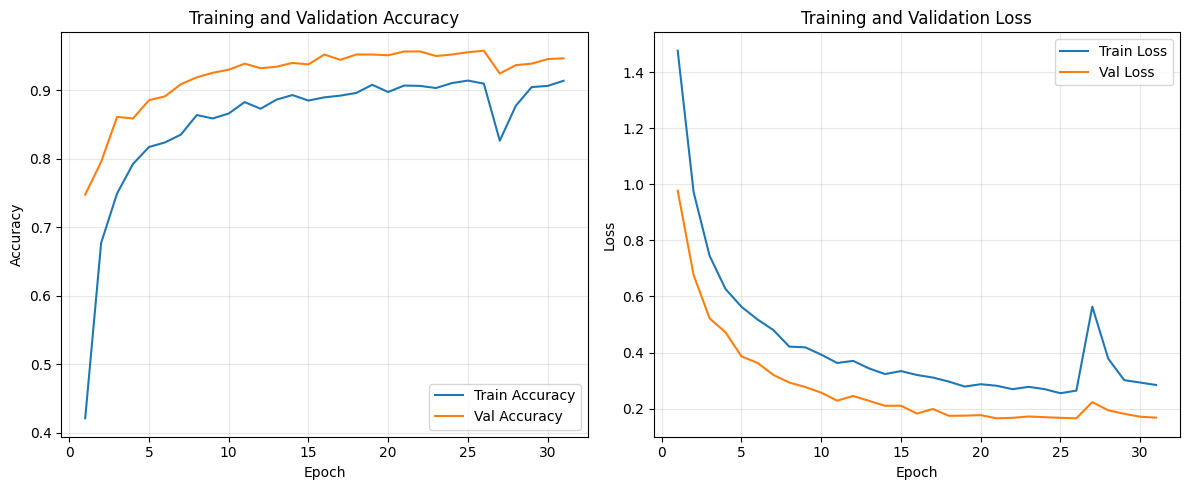

In [19]:
# Plot training and validation accuracy/loss
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics from warmup and optional fine-tune
acc = list(history.history.get('accuracy', []))
val_acc = list(history.history.get('val_accuracy', []))
loss = list(history.history.get('loss', []))
val_loss = list(history.history.get('val_loss', []))

try:
    acc += list(history_ft.history.get('accuracy', []))
    val_acc += list(history_ft.history.get('val_accuracy', []))
    loss += list(history_ft.history.get('loss', []))
    val_loss += list(history_ft.history.get('val_loss', []))
except NameError:
    pass

epochs = np.arange(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

---
## 📊 Evaluation & Metrics

This section evaluates the trained EfficientNetB0 model on the **test set** and visualises:
- Learning rate schedule across epochs
- Confusion matrix (normalised & raw counts)
- Per-class classification report (precision, recall, F1-score)
- Per-class accuracy bar chart
- Prediction gallery with true vs predicted labels


### 🔧 Dependencies

In [20]:
# Ensure scikit-learn is available (needed for classification_report & confusion_matrix)
try:
    import sklearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")


scikit-learn version: 1.6.1


### 📉 Learning Rate Schedule

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Collect LR history from warmup + fine-tune phases
lr_warmup = history.history.get('lr', [])
lr_finetune = []
try:
    lr_finetune = history_ft.history.get('lr', [])
except NameError:
    pass

all_lr = list(lr_warmup) + list(lr_finetune)

if all_lr:
    fig, ax = plt.subplots(figsize=(10, 4))
    epochs_lr = np.arange(1, len(all_lr) + 1)
    ax.semilogy(epochs_lr, all_lr, color='darkorange', linewidth=2.5, marker='o',
                markersize=4, label='Learning Rate')

    # Mark the boundary between warmup and fine-tune
    if lr_warmup and lr_finetune:
        boundary = len(lr_warmup)
        ax.axvline(boundary + 0.5, color='gray', linestyle='--', alpha=0.7,
                   label='Fine-tune start')
        ax.text(boundary + 0.7, max(all_lr) * 0.6, 'Fine-tune phase',
                fontsize=9, color='gray')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate (log scale)', fontsize=12)
    ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("LR history not captured. Keras only stores 'lr' when ReduceLROnPlateau is active.")
    print("Re-run training with the callbacks to see the LR schedule plot.")

LR history not captured. Keras only stores 'lr' when ReduceLROnPlateau is active.
Re-run training with the callbacks to see the LR schedule plot.


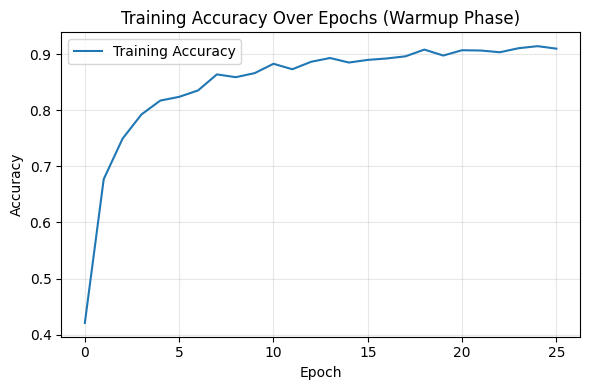

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy Over Epochs (Warmup Phase)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 🔢 Confusion Matrix

Generating predictions on test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step


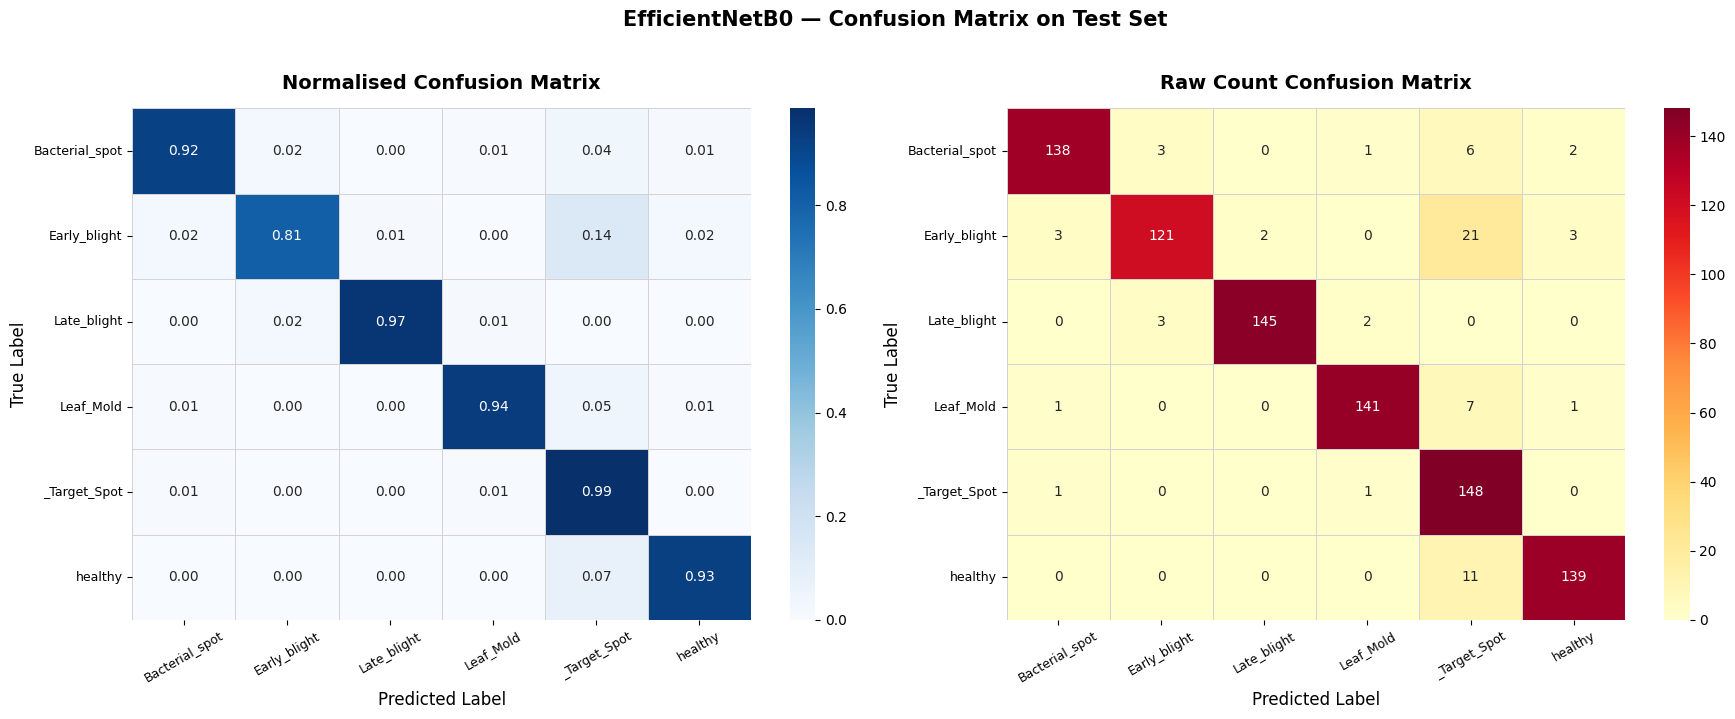

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Generate predictions on the test set ──────────────────────────────────
# test_generator has shuffle=False so predictions align with true labels
print("Generating predictions on test set...")
test_generator.reset()
test_steps_cm = len(test_generator)

y_pred_prob = model.predict(test_generator, steps=test_steps_cm, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())
# Shorten names for display
short_names = [n.replace('Tomato_', '').replace('Tomato__', '') for n in class_names]

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title, fmt, cmap in zip(
    axes,
    [cm_norm, cm],
    ['Normalised Confusion Matrix', 'Raw Count Confusion Matrix'],
    ['.2f', 'd'],
    ['Blues', 'YlOrRd']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap=cmap,
        xticklabels=short_names, yticklabels=short_names,
        ax=ax, linewidths=0.5, linecolor='lightgray',
        annot_kws={'size': 10}
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('EfficientNetB0 — Confusion Matrix on Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📋 Per-class Classification Report

In [24]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true, y_pred,
    target_names=short_names,
    output_dict=True
)

# Convert to DataFrame for a cleaner display
df_report = pd.DataFrame(report_dict).T
df_report = df_report.round(3)

# Style the table
styled = (
    df_report.style
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0.5, vmax=1.0)
    .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1-score': '{:.3f}', 'support': '{:.0f}'})
    .set_caption('EfficientNetB0 — Classification Report (Test Set)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px'), ('padding', '6px')]},
        {'selector': 'td', 'props': [('font-size', '12px'), ('padding', '5px')]},
    ])
)

print(classification_report(y_true, y_pred, target_names=short_names))
display(styled)


                precision    recall  f1-score   support

Bacterial_spot       0.97      0.92      0.94       150
  Early_blight       0.95      0.81      0.87       150
   Late_blight       0.99      0.97      0.98       150
     Leaf_Mold       0.97      0.94      0.96       150
  _Target_Spot       0.77      0.99      0.86       150
       healthy       0.96      0.93      0.94       150

      accuracy                           0.92       900
     macro avg       0.93      0.92      0.93       900
  weighted avg       0.93      0.92      0.93       900



,precision,recall,f1-score,support
Bacterial_spot,0.965,0.920,0.942,150
Early_blight,0.953,0.807,0.874,150
Late_blight,0.986,0.967,0.976,150
Leaf_Mold,0.972,0.940,0.956,150
_Target_Spot,0.767,0.987,0.863,150
healthy,0.959,0.927,0.942,150
accuracy,0.924,0.924,0.924,1
macro avg,0.934,0.924,0.926,900
weighted avg,0.934,0.924,0.926,900


### 📊 Per-class Accuracy

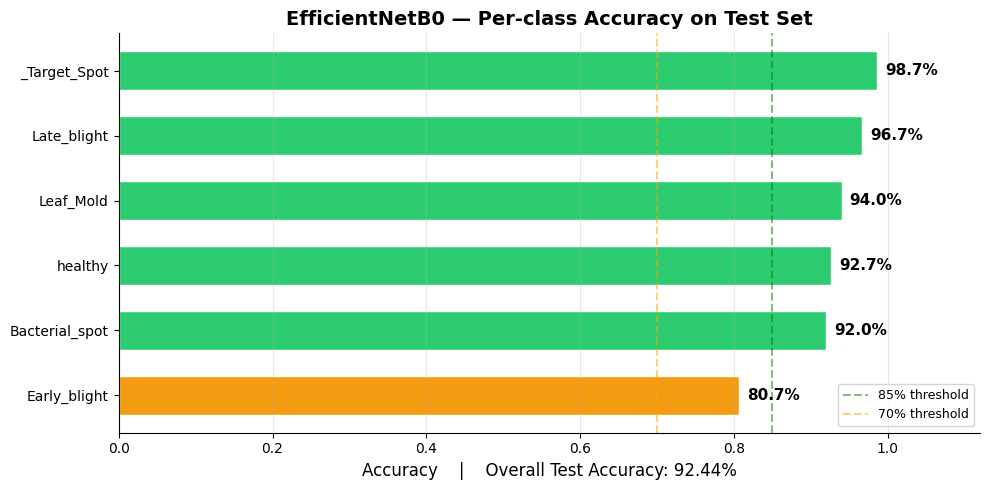

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Compute per-class accuracy from the confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Sort by accuracy descending
sorted_idx = np.argsort(per_class_acc)
sorted_names = [short_names[i] for i in sorted_idx]
sorted_acc   = per_class_acc[sorted_idx]

# Color: green if >= 0.85, yellow if >= 0.70, red otherwise
colors = ['#2ecc71' if a >= 0.85 else '#f39c12' if a >= 0.70 else '#e74c3c'
          for a in sorted_acc]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_names, sorted_acc, color=colors, edgecolor='white', height=0.6)

# Annotate bars
for bar, acc_val in zip(bars, sorted_acc):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{acc_val:.1%}', va='center', fontsize=11, fontweight='bold'
    )

ax.set_xlim(0, 1.12)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('EfficientNetB0 — Per-class Accuracy on Test Set', fontsize=14, fontweight='bold')
ax.axvline(0.85, color='green',  linestyle='--', alpha=0.5, label='85% threshold')
ax.axvline(0.70, color='orange', linestyle='--', alpha=0.5, label='70% threshold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Overall accuracy annotation
overall = np.sum(np.diag(cm)) / np.sum(cm)
ax.set_xlabel(f'Accuracy    |    Overall Test Accuracy: {overall:.2%}', fontsize=12)

plt.tight_layout()
plt.show()


### 🖼️ Prediction Gallery

Found 900 images belonging to 6 classes.


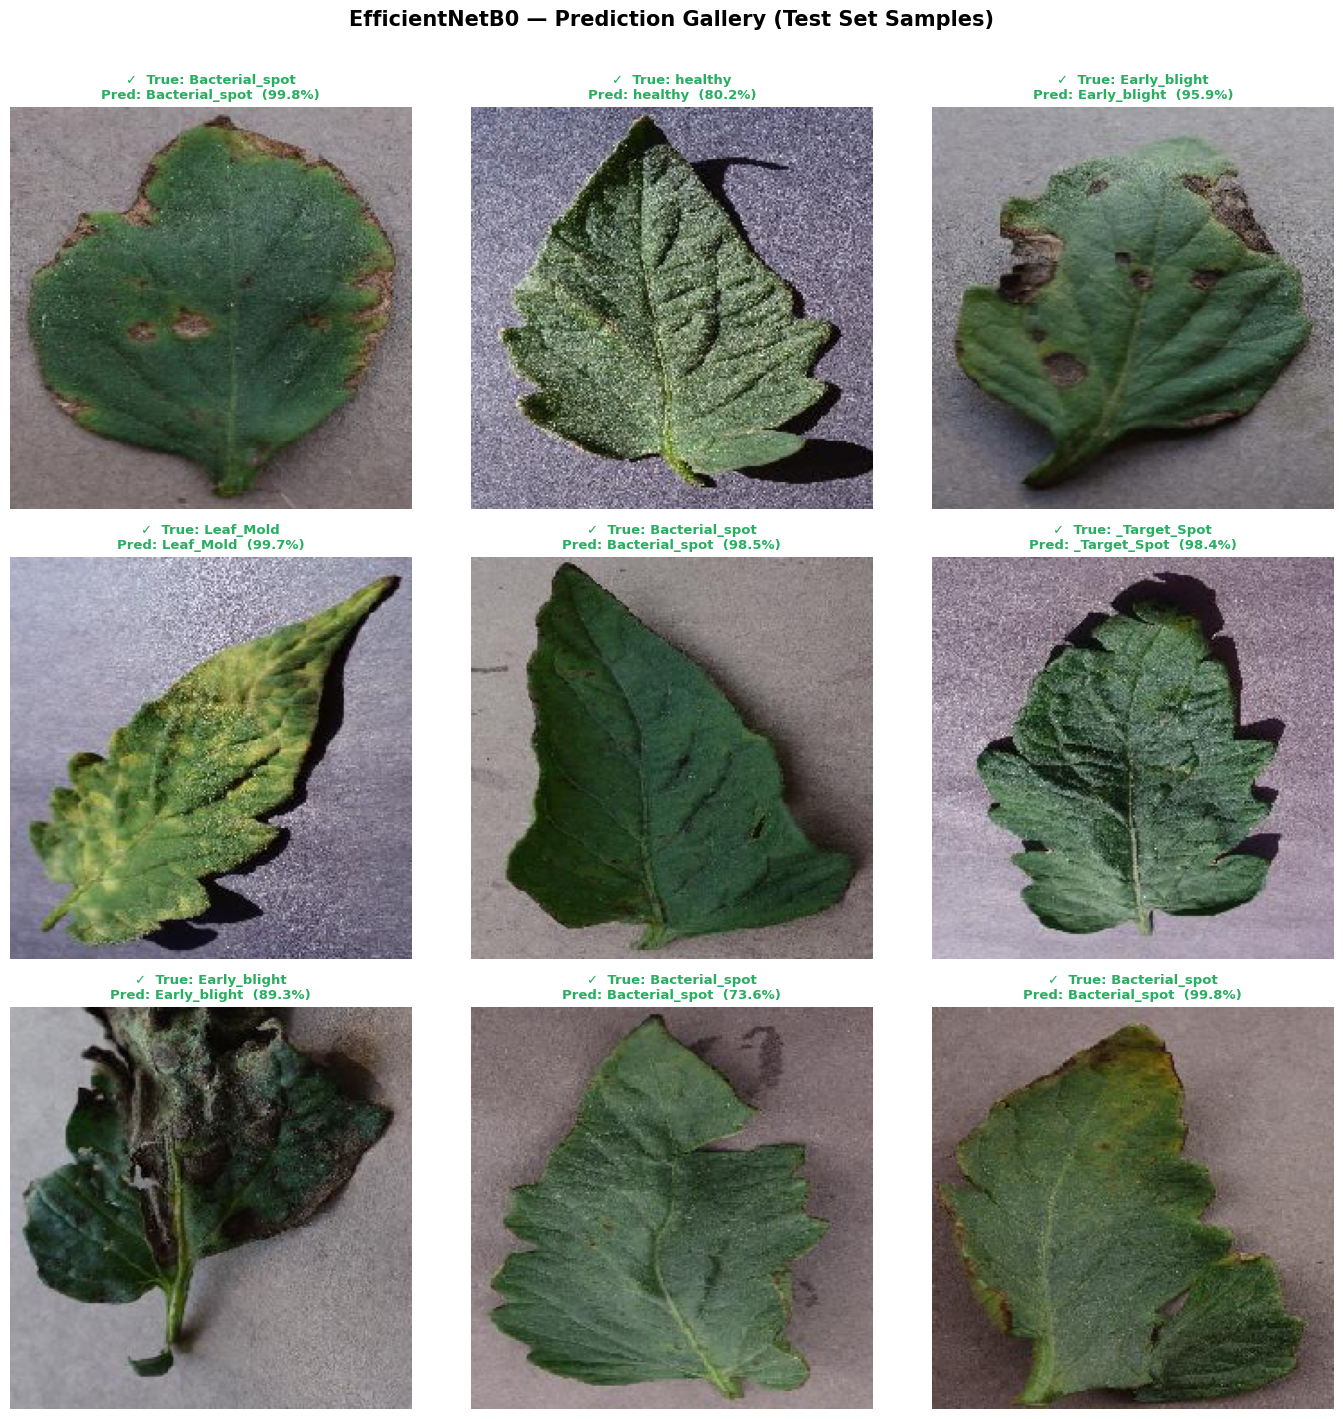


Green border = correct prediction | Red border = wrong prediction


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Pull one raw batch from test directory for display (without EfficientNet preprocessing)
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG

raw_gen = IDG(rescale=1.0/255)
raw_test = raw_gen.flow_from_directory(
    test_generator.directory,
    target_size=(224, 224),
    batch_size=9,
    class_mode='sparse',
    shuffle=True,
    seed=42
)

# Get one batch of raw images and their true labels
raw_images, raw_labels = next(raw_test)

# Get preprocessed batch for prediction
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
preproc_images = eff_preprocess(raw_images * 255.0)
preds_prob = model.predict(preproc_images, verbose=0)
preds = np.argmax(preds_prob, axis=1)
confs = np.max(preds_prob, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('EfficientNetB0 — Prediction Gallery (Test Set Samples)',
             fontsize=15, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(raw_images[i])

    true_cls = short_names[int(raw_labels[i])]
    pred_cls = short_names[preds[i]]
    conf     = confs[i]
    correct  = int(raw_labels[i]) == preds[i]

    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    status_icon = '✓' if correct else '✗'
    title_color = '#27ae60' if correct else '#c0392b'

    ax.set_title(
        f'{status_icon}  True: {true_cls}\nPred: {pred_cls}  ({conf:.1%})',
        fontsize=9.5, color=title_color, fontweight='bold', pad=6
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"\nGreen border = correct prediction | Red border = wrong prediction")


In [30]:
# Save trained model to the project's models directory (see setup cell)
save_path = MODELS_DIR / 'tomato_effnetb0.keras'
model.save(save_path)
print(f"Saved model to: {save_path.resolve()}")

# Optionally also save best checkpoint copy if exists
checkpoint_path = MODELS_DIR / 'best_effnetb0.keras'
if checkpoint_path.exists():
    # Save the best checkpoint with a new prefix 'latest_'
    dest_ckpt = MODELS_DIR / 'latest_best_effnetb0.keras'
    import shutil
    shutil.copy2(checkpoint_path, dest_ckpt)
    print(f"Copied best checkpoint to: {dest_ckpt.resolve()}")

Saved model to: /content/PlantVillage_Project/models/tomato_effnetb0.keras
Copied best checkpoint to: /content/PlantVillage_Project/models/latest_best_effnetb0.keras
